In [1]:
from samap.mapping import SAMAP
from samap.analysis import (get_mapping_scores, GenePairFinder, transfer_annotations,
                            sankey_plot, chord_plot, CellTypeTriangles, 
                            ParalogSubstitutions, FunctionalEnrichment,
                            convert_eggnog_to_homologs, GeneTriangles)
from samalg import SAM
import pandas as pd
from Bio import SeqIO
from samap.utils import (save_samap, load_samap)
import scanpy as sc
import matplotlib.colors
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy import sparse 
from scipy import cluster
import seaborn as sns
import random
import sklearn
from scipy.stats import poisson
from sklearn.neighbors import KernelDensity
import time
import dill
from scipy.optimize import minimize
import pickle
from matplotlib.colors import LinearSegmentedColormap
import os

In [2]:
nt_mapping = {'Gaba-Chol':'Chol',
             'Chol':'Chol',
             'Glut-Chol':'Chol',
             'Glut-Gaba-Dopa':'Dopa',
             'Gaba-Dopa':'Dopa',
             'Glut-Dopa':'Dopa',
             'Gaba':'Gaba',
             'Glut':'Glut',
             'Glut-Gaba':'Gaba-Glut',
             'Gaba-Gly':'Gly',
             'Gaba-Hist':'Hist',
             'Glut-Sert':'Sert',
             'unclear':'Unclear',
             'Sert':'Sert',
             'Glut-Gaba-Hist':'Hist'}

In [3]:
NT_df = pd.DataFrame(data = np.zeros((5,len(list(set(nt_mapping.values()))))),columns = list(set(nt_mapping.values())), index = ['mo','cj','ac','xt','dr'])

In [4]:
sam_mo = SAM()
sam_mo.load_data('../../Active_SAM_joined/SAM_MO_soupx_plus5_cleaned_NN_04142026.h5ad')

sam_cj = SAM()
sam_cj.load_data('../../Active_SAM_joined/SAM_CJ_joined_v2_cleaned_03122025.h5ad')

sam_ac = SAM()
sam_ac.load_data('../../Active_SAM_joined/SAM_AC_ncbi_soupx_cleaned_03122025.h5ad')

sam_xt = SAM()
sam_xt.load_data('../../Active_SAM_joined/SAM_XT_joined_Slc17a6_cleaned_03122205.h5ad')

sam_dr = SAM()
sam_dr.load_data('../../Active_SAM_joined/SAM_DR_ncbi_joined_cleaned_07172026.h5ad')

In [5]:
#input organism and obs column with neurotransmitter
NT_level = 'neurotransmitter_v3'

In [6]:
allNT = set(sam_mo.adata.obs[NT_level]) | set(sam_cj.adata.obs[NT_level]) | set(sam_ac.adata.obs[NT_level]) | set(sam_xt.adata.obs[NT_level]) | set(sam_dr.adata.obs[NT_level])
print(allNT - set(nt_mapping.keys()))
print(set(nt_mapping.keys()) - allNT)

set()
set()


In [7]:
for item in sam_mo.adata.obs[NT_level].unique():
    NT_df.loc['mo',nt_mapping[item]] += len(sam_mo.adata[sam_mo.adata.obs[NT_level] == item])
    
for item in sam_cj.adata.obs[NT_level].unique():
    NT_df.loc['cj',nt_mapping[item]] += len(sam_cj.adata[sam_cj.adata.obs[NT_level] == item])
    
for item in sam_ac.adata.obs[NT_level].unique():
    NT_df.loc['ac',nt_mapping[item]] += len(sam_ac.adata[sam_ac.adata.obs[NT_level] == item])
    
for item in sam_xt.adata.obs[NT_level].unique():
    NT_df.loc['xt',nt_mapping[item]] += len(sam_xt.adata[sam_xt.adata.obs[NT_level] == item])
    
for item in sam_dr.adata.obs[NT_level].unique():
    NT_df.loc['dr',nt_mapping[item]] += len(sam_dr.adata[sam_dr.adata.obs[NT_level] == item])

In [8]:
NT_df

,Gaba,Sert,Gly,Gaba-Glut,Dopa,Unclear,Hist,Glut,Chol
mo,34126.0,0.0,0.0,0.0,889.0,0.0,665.0,37938.0,337.0
cj,30610.0,0.0,0.0,0.0,124.0,19142.0,282.0,24451.0,149.0
ac,17552.0,168.0,36.0,1978.0,120.0,11380.0,106.0,16441.0,119.0
xt,15621.0,117.0,2984.0,1240.0,476.0,3966.0,248.0,17426.0,143.0
dr,11292.0,0.0,0.0,6880.0,0.0,21452.0,60.0,21746.0,0.0


In [9]:
NT_df = NT_df[['Gaba','Glut','Gaba-Glut','Sert','Dopa','Gly','Hist','Chol']]

In [10]:
NT_df_gg = NT_df[['Gaba-Glut','Sert','Dopa','Gly','Hist','Chol']]

In [11]:
NT_df_gg = NT_df_gg.div(NT_df_gg.sum(axis=1), axis=0)

In [12]:
NT_df = NT_df.div(NT_df.sum(axis=1), axis=0)

In [13]:
NT_df = NT_df.loc[['mo','cj','ac','xt','dr'],:]

In [14]:
NT_df = NT_df.rename({'mo':'prairie vole','cj':'japanese quail','ac':'green anole','xt':'clawed frog','dr':'zebrafish'},axis=0)

In [15]:
NT_df

,Gaba,Glut,Gaba-Glut,Sert,Dopa,Gly,Hist,Chol
prairie vole,0.461443,0.512988,0.000000,0.000000,0.012021,0.000000,0.008992,0.004557
japanese quail,0.550381,0.439640,0.000000,0.000000,0.002230,0.000000,0.005070,0.002679
green anole,0.480613,0.450192,0.054162,0.004600,0.003286,0.000986,0.002903,0.003258
clawed frog,0.408339,0.455522,0.032414,0.003058,0.012443,0.078003,0.006483,0.003738
zebrafish,0.282455,0.543949,0.172095,0.000000,0.000000,0.000000,0.001501,0.000000


In [16]:
NT_df_gg = NT_df_gg.rename({'mo':'prairie vole','cj':'japanese quail','ac':'green anole','xt':'clawed frog','dr':'zebrafish'},axis=0)

In [21]:
color = ['red','blue','black','black','black','black','black','black','black','black']
color_gg = ['#0a9864','#503090','#f9ed4e','#801c59','#f37527','#85c77e']

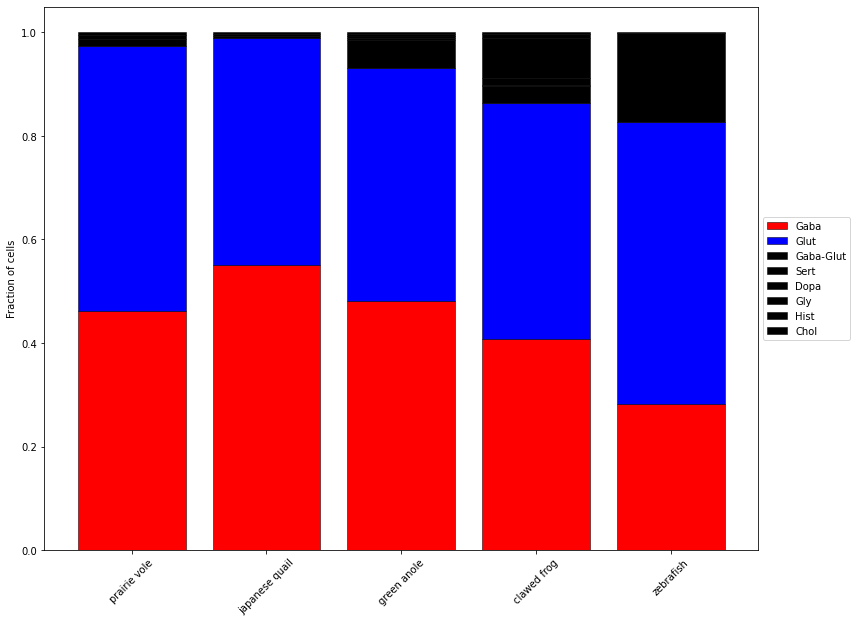

In [22]:
plt.rcParams.update({'font.size': 20}) 
ax = NT_df.plot.bar(stacked=True, figsize = (16,10), width = .8, color = color,edgecolor="black",linewidth=0.5)
# Shrink current axis by 20%
box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])

# Put a legend to the right of the current axis
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.ylabel('Fraction of cells')
plt.xticks(rotation=45) 
plt.savefig('../../Figures/Figures_08022026/NT_stacked_bar_08042026.pdf',bbox_inches='tight')
plt.savefig('../../Figures/Figures_08022026/NT_stacked_bar_08042026.svg',bbox_inches='tight')
plt.show()

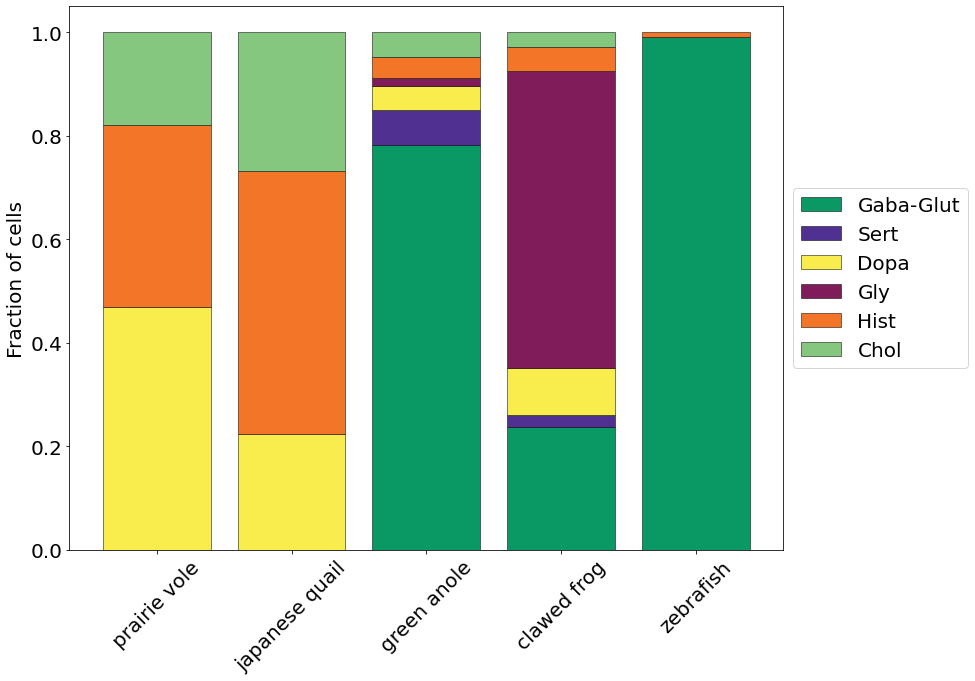

In [23]:
plt.rcParams.update({'font.size': 20}) 
ax = NT_df_gg.plot.bar(stacked=True, figsize = (16,10), width = .8, color = color_gg,edgecolor="black",linewidth=0.5)
# Shrink current axis by 20%
box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])

# Put a legend to the right of the current axis
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.ylabel('Fraction of cells')
plt.xticks(rotation=45) 
plt.savefig('../../Figures/Figures_08022026/NT_gg_stacked_bar_08042026.pdf',bbox_inches='tight')
plt.savefig('../../Figures/Figures_08022026/NT_gg_stacked_bar_08042026.svg',bbox_inches='tight')
plt.show()